['/exp/sbnd/data/users/lpelegri/cafpyana', '/cvmfs/larsoft.opensciencegrid.org/spack-fnal-v1.0.0/opt/spack/linux-x86_64_v2/root-6.28.06-py-numpy-1.26.4-bjfwdigla2ihyygih63foelrl4jedvx2/lib/root', '/cvmfs/larsoft.opensciencegrid.org/spack-fnal-v1.0.0/opt/spack/linux-x86_64_v2/python-3.10.16-artasofgepjz3l7wggy7im4zv2m4dfyf/lib/python310.zip', '/cvmfs/larsoft.opensciencegrid.org/spack-fnal-v1.0.0/opt/spack/linux-x86_64_v2/python-3.10.16-artasofgepjz3l7wggy7im4zv2m4dfyf/lib/python3.10', '/cvmfs/larsoft.opensciencegrid.org/spack-fnal-v1.0.0/opt/spack/linux-x86_64_v2/python-3.10.16-artasofgepjz3l7wggy7im4zv2m4dfyf/lib/python3.10/lib-dynload', '', '/exp/sbnd/data/users/lpelegri/cafpyana/envs/venv_py310_cafpyana/lib/python3.10/site-packages', '/exp/sbnd/data/users/lpelegri/cafpyana/envs/venv_py310_cafpyana/lib/python3.10/site-packages/xrootd-5.6.9-py3.10-linux-x86_64.egg', '/home/lpelegri/.local/lib/python3.10/site-packages', '/cvmfs/larsoft.opensciencegrid.org/spack-fnal-v1.0.0/opt/spack/lin

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

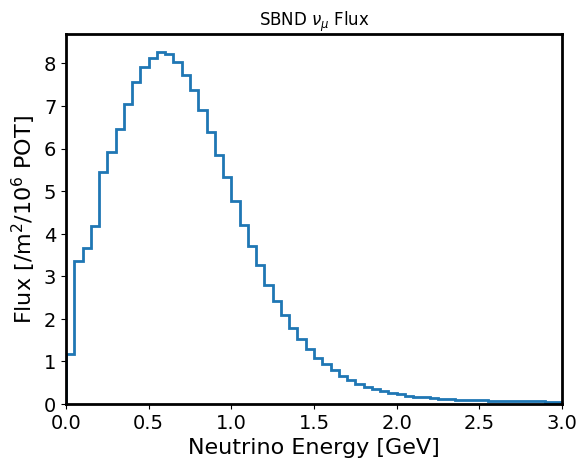

In [1]:
print(sys.path)

from analysis_village.cc1pi.var_configs import *

import os
import sys
import lmfit
import numpy as np
import math
import uproot as uproot
import pickle
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.colors
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import ticker
from matplotlib.ticker import (AutoMinorLocator, MultipleLocator)
from matplotlib import gridspec

from analysis_village.unfolding.wienersvd import *
from analysis_village.unfolding.unfolding_inputs import *

from analysis_village.cc1pi.HelperFunctions import HelperFunctions
from analysis_village.cc1pi.Constants import CTE as CTE
from analysis_village.cc1pi.CutMasks.CutMasks import *
from analysis_village.cc1pi.CutMasks.MaskUtils import *
from analysis_village.cc1pi.DataFrameUtils import DFCleaning
from analysis_village.cc1pi.DataFrameUtils.DFLoading import *
from analysis_village.cc1pi.GraphUtils.GraphsUtils import *
from analysis_village.cc1pi.GraphUtils.Utils import *

# import this repo's classes
import pyanalib.pandas_helpers as ph
import pyanalib.split_df_helpers as splh
import pyanalib.stat_helpers as sh

from pyanalib.split_df_helpers import *
from analysis_village.cc1pi.systematics.final_variable_configs import VariableConfig
from analysis_village.cc1pi.systematics.utils import *
from analysis_village.cc1pi.systematics.constants import *
from pyanalib.covariance import *
from analysis_village.cc1pi.DataFrameUtils.DFLoading import *

np.seterr(divide='ignore', invalid='ignore', over='ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D 
from matplotlib.patches import Patch
from matplotlib.colors import to_rgba
import matplotlib.gridspec as gridspec
from matplotlib.legend_handler import HandlerTuple, HandlerBase

import numpy as np
import numpy as np
from scipy.stats import chi2 as chi2_dist

def get_chi2(data, mc, cov, n_params=0):
    # Ensure inputs are numpy arrays
    data = np.atleast_1d(data)
    mc = np.atleast_1d(mc)
    
    # Create mask (e.g., where mc > 0)
    mask = (mc > 0)
    
    # Check if mask dimension matches data dimension
    if mask.shape[0] != data.shape[0]:
        print(f"Warning: Mask length {mask.shape[0]} doesn't match data length {data.shape[0]}")
        # Fallback: if data is a single value, don't use the 40-bin mask
        if data.size == 1:
            mask = np.array([True])
    
    data_filtered = data[mask]
    mc_filtered = mc[mask]

    # Slice rows AND columns of the covariance matrix
    cov_filtered  = cov[np.ix_(mask, mask)]
    
    # 3. Check if we have enough bins left to do a calculation
    n_bins = len(data_filtered)
    if n_bins <= n_params:
        return np.nan, 0, np.nan

    # 4. Compute χ² using filtered data
    delta = mc_filtered - data_filtered
    
    try:
        # Using solve is numerically more stable than inv()
        # It solves: cov_filtered * x = delta, then computes delta * x
        chi2 = delta @ np.linalg.solve(cov_filtered, delta)
    except np.linalg.LinAlgError:
        # Fallback if matrix is still singular (e.g., highly correlated empty bins)
        return np.nan, n_bins - n_params, np.nan

    ndof = n_bins - n_params
    reduced_chi2 = chi2 / ndof if ndof > 0 else np.nan
    pval = chi2_dist.sf(chi2, ndof) if ndof > 0 else np.nan

    return chi2, ndof, pval

def get_stat_covariance_matrix(cv_contents, sum_w2):
    """
    cv_contents: array of bin contents (sum of weights)
    sum_w2: array of the sum of the squares of the weights per bin
    """
    cv_contents = np.asarray(cv_contents)
    sum_w2 = np.asarray(sum_w2)
    n_bins = len(cv_contents)

    # 1. Variance for weighted Poisson is Sum(W^2)
    cov = np.diag(sum_w2)

    # 2. Fractional covariance: Var / (Content^2) = Sum(W^2) / (Sum W)^2
    with np.errstate(divide='ignore', invalid='ignore'):
        # This is the squared fractional error
        frac_variance = np.where(cv_contents > 0, sum_w2 / (cv_contents**2), 0.0)
        cov_frac = np.diag(frac_variance)

    # 3. Correlation matrix
    corr = np.eye(n_bins)

    return {
        "cov": cov,
        "cov_frac": cov_frac,
        "corr": corr,
    }

def plot_stacked_histogram_with_ratio(
    mc_df,
    data_df,
    config,
    cov_frac_matrix = None,
    cov_matrix = None,
    title: str = None,
    weight_column: tuple = None,
    data_pot: float = None,
    show_stats: bool = True,
    symmetric_ratio: bool = False,
    divide_by_bin_width: bool = False
):
    # 1. Pre-processing and Scaling
    slice_levels = ['__ntuple', 'entry', 'rec.slc..index']
    
    mc_data = mc_df[config.var_evt_reco_col]
    mc_types = mc_df[('truth','nu_categ','','','','')]
    mc_weights = mc_df[weight_column] if weight_column in mc_df.columns else pd.Series(1.0, index=mc_df.index)

    # --- Palette Selection ---
    present_categories = set(mc_types.dropna().unique())
    palettes = [category_colors, category_colors_pfp, proton_distinction_category_colors, genie_category_colors]
    
    chosen_map = category_colors
    max_overlap = -1
    for p in palettes:
        overlap = len(present_categories.intersection(p.keys()))
        if overlap > max_overlap:
            max_overlap = overlap
            chosen_map = p

    # 2. Sorting Categories
    category_totals = [(t, mc_weights[mc_types == t].sum()) for t in mc_types.dropna().unique()]
    signal_keys = ["CC1pi"]
    signals = sorted([x for x in category_totals if x[0] in signal_keys], key=lambda x: x[1], reverse=True)
    backgrounds = sorted([x for x in category_totals if x[0] not in signal_keys], key=lambda x: x[1], reverse=True)
    
    sorted_types = [x[0] for x in signals + backgrounds]
    stack_data_mc = [mc_data[mc_types == t].dropna() for t in sorted_types]
    stack_weights = [mc_weights[mc_types == t].loc[mc_data[mc_types == t].dropna().index] for t in sorted_types]

    # 3. Setup Figure
    fig = plt.figure(figsize=(10, 8))
    gs = gridspec.GridSpec(2, 1, height_ratios=[4, 1], hspace=0.07)
    ax_top = fig.add_subplot(gs[0])
    ax_ratio = fig.add_subplot(gs[1], sharex=ax_top)

    # 4. TOP PLOT
    max_bin_edge = config.bins[-1]
    stack_mc_clipped = [np.clip(data, config.bins[0], max_bin_edge) for data in stack_data_mc] 
        
    colors = [chosen_map.get(t, "#7f7f7f") for t in sorted_types]
    all_mc_weights = pd.concat(stack_weights)
    
    mc_sum, bins = np.histogram(
        pd.concat(stack_mc_clipped),
        bins=config.bins,
        weights=all_mc_weights
    )

    
    bin_centers = (bins[:-1] + bins[1:]) / 2
    bin_widths = np.diff(bins)
    
    # --- MC UNCERTAINTY ---
    # If a fractional covariance matrix is provided, use it
    if cov_frac_matrix is not None:
        frac_err = np.sqrt(np.diag(cov_frac_matrix))
        mc_error = frac_err * mc_sum    
    else:
        mc_sum_w2, _ = np.histogram(
            pd.concat(stack_mc_clipped),
            bins=config.bins,
            weights=all_mc_weights**2
        )
        mc_error = np.sqrt(mc_sum_w2)
        cov_matrix = get_stat_covariance_matrix(mc_sum, mc_sum_w2)["cov"]
        cov_frac_matrix = get_stat_covariance_matrix(mc_sum, mc_sum_w2)["cov_frac"]

    
 
    
    
    data = data_df[config.var_evt_reco_col].dropna()
    data_weights = data_df[weight_column] if weight_column in data_df.columns else pd.Series(1.0, index=mc_df.index)
    data_clipped = np.clip(data, config.bins[0], max_bin_edge)
    data_counts, _ = np.histogram(data_clipped, bins=bins, weights = data_weights)
    data_plot_counts = data_counts.astype(float)
    data_sum_w2, _ = np.histogram(
            data_clipped,
            bins=bins,
            weights=data_weights**2
        )
    data_errors = np.sqrt(data_sum_w2)

    # 6. STATISTICS   
    ret_stats_data_rate = get_stat_covariance_matrix(data_plot_counts , data_plot_counts)    
    chi2_val, ndof, p_val = get_chi2(data_counts, mc_sum, cov_matrix + ret_stats_data_rate["cov"])

    if divide_by_bin_width:
        mc_sum /= bin_widths
        mc_error /= bin_widths
        data_plot_counts /= bin_widths
        data_errors /= bin_widths
        # FIX FOR INDEX ERROR: Map every event to its bin width and divide weight
        new_stack_weights = []
        for i, d in enumerate(stack_mc_clipped):
            bin_indices = np.clip(np.digitize(d, bins) - 1, 0, len(bin_widths) - 1)
            new_stack_weights.append(stack_weights[i] / bin_widths[bin_indices])
        stack_weights = new_stack_weights


    ax_top.hist(stack_mc_clipped, bins=bins, stacked=True, weights=stack_weights,
                histtype='stepfilled', color=colors, alpha=0.3)
    ax_top.hist(stack_mc_clipped, bins=bins, stacked=True, weights=stack_weights,
                histtype='step', color=colors, linewidth=2)

    ax_top.bar(bin_centers, 2*mc_error, bottom=mc_sum-mc_error, width=bin_widths, 
               edgecolor='grey', facecolor='grey', alpha=0.2, linewidth=0)
    ax_top.bar(bin_centers, 2*mc_error, bottom=mc_sum-mc_error, width=bin_widths,
               edgecolor='grey', facecolor='none', hatch='////', alpha=0.5, linewidth=0)
    ax_top.errorbar(bin_centers, data_plot_counts, yerr=data_errors, xerr=bin_widths/2, 
                    fmt='ko', markersize=6, zorder=10, capsize=0)

    # 5. RATIO PLOT CALCULATION
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.divide(data_plot_counts, mc_sum, out=np.zeros_like(data_plot_counts), where=mc_sum!=0)
        ratio_error = np.divide(data_errors, mc_sum, out=np.zeros_like(data_errors), where=mc_sum!=0)
        mc_rel_error = np.divide(mc_error, mc_sum, out=np.zeros_like(mc_error), where=mc_sum!=0)
    
    # --- DYNAMIC Y-LIMIT CALCULATION ---
    # We look at the deviation from 1.0 (abs(ratio - 1)) + the error bar
    # and find the maximum such value across all bins.
    valid_ratio = (mc_sum > 0)

    # --- SYMMETRIC Y-LIMIT CALCULATION (MAXIMUM EXTENT) ---
    valid_ratio = (mc_sum > 0)
    if np.any(valid_ratio) and symmetric_ratio:
        data_extrema = np.maximum(np.abs((ratio[valid_ratio] + ratio_error[valid_ratio]) - 1), 
                                  np.abs((ratio[valid_ratio] - ratio_error[valid_ratio]) - 1))
        mc_extrema = mc_rel_error[valid_ratio]
        # Take the global maximum across all bins and all components
        max_deviation = np.max(np.maximum(data_extrema, mc_extrema))
        
        y_padding = max_deviation * 1.4
        y_padding = max(y_padding, 0.1)
        
        ax_ratio.set_ylim(1 - y_padding, 1 + y_padding)
    elif np.any(valid_ratio):
        # Distance of point (including error) from 1.0
        max_deviation = np.max(np.abs(ratio[valid_ratio] - 1) + ratio_error[valid_ratio])
        # Add 10% headroom and clip to a maximum of 0.5 (which results in ylim 0.5 to 1.5)
        y_padding = min(max_deviation * 1.4, 0.75)
        # Ensure we have a minimum padding so the plot isn't flat
        y_padding = max(y_padding, 0.1)

        ax_ratio.set_ylim(1 - y_padding, 1 + y_padding)
    else:
        ax_ratio.set_ylim(0.5, 1.5)
        
        
    ax_ratio.bar(bin_centers, 2*mc_rel_error, bottom=1-mc_rel_error, width=bin_widths,
                 edgecolor='grey', facecolor='grey', alpha=0.2, linewidth=0)
    ax_ratio.bar(bin_centers, 2*mc_rel_error, bottom=1-mc_rel_error, width=bin_widths,
                 edgecolor='grey', facecolor='none', hatch='////', alpha=0.4, linewidth=0)
    ax_ratio.errorbar(bin_centers, ratio, yerr=ratio_error, xerr=bin_widths/2, fmt='ko', markersize=6, capsize=0)
    ax_ratio.axhline(1.0, color='#d62728', linestyle='--', linewidth=2)


    # 5.5 VERTICAL CUT LINE
    cut_val = -999 # Use getattr to be safe
    draw_cut = (cut_val != -999)
    
    if draw_cut:
        # Low zorder (1) puts it behind most elements; 
        # Standard hist is usually 1, so 1.5 or 2 keeps it visible but "back"
        for ax in [ax_top, ax_ratio]:
            ax.axvline(cut_val, color='black', linestyle='--', linewidth=2, zorder=2)
        
        # Create handle for legend
        cut_hand = Line2D([0], [0], color='black', linestyle='--', linewidth=2, label='Selection Cut')
        
    
    # 7. LEGEND
    total_data_counts = len(data_clipped)
    mc_hand = [Patch(facecolor=to_rgba(chosen_map.get(t, "#7f7f7f"), 0.3), 
                     edgecolor=chosen_map.get(t, "#7f7f7f"), 
                     label=bkg_name_nice_map.get(t, t)) for t in sorted_types]

    err_label = 'MC Stat. Error'
    if show_stats:
        err_label = 'MC Total Error'
        
    err_hand = Patch(edgecolor='grey', facecolor='none', hatch='////', alpha=0.5, label = err_label)
    dat_hand = Line2D([0], [0], color='black', marker='o', linestyle='', label= 'Data', markersize=8)

    if show_stats:
        chi2_str = f"$\chi^{2}$ / ndf: {chi2_val:.2f} / {ndof} = {chi2_val/ndof:.3f}"
        p_value_str = f"$p_{{value}}$ = {p_val:.3f}"
        data_str = f'$N_{{\\mathrm{{Data}}}} = {total_data_counts}$'
        chi2_handle = Patch(color='none', label=chi2_str)
        p_value_handle = Patch(color='none', label=p_value_str)
        N_data_evts_handle = Patch(color='none', label=data_str)
    

    all_handles = mc_hand + [err_hand, dat_hand]
    all_labels = [h.get_label() for h in mc_hand] + [err_label ,'Data']
    if draw_cut:
        all_handles.append(cut_hand)
        all_labels.append(cut_hand.get_label())
    if show_stats:
        all_handles +=  [chi2_handle, p_value_handle, N_data_evts_handle]
        all_labels += [chi2_str, p_value_str, data_str]
        
    n_cols = (len(all_handles) + 3) // 4 
    
        
    leg = ax_top.legend(
        handles=all_handles, labels=all_labels,
        loc='upper center' , ncol=n_cols,
        fontsize=12, framealpha=1.0, edgecolor='black', fancybox=False, 
        borderaxespad=1, columnspacing=1.5, handlelength=1.5, handletextpad=0.5,
    )
    leg.get_frame().set_linewidth(1.5)

    plt.draw() 
    if show_stats:
        texts = leg.get_texts()
        for t in texts[-3:]:
            t.set_position((-28, 0))

    # 8. FINAL STYLING
    ax_top.set_xlim(bins[0], bins[-1])
    ax_top.set_ylim(0, ax_top.get_ylim()[1] * 1.5)

    ylabel = f'Candidate Slices'
    if divide_by_bin_width:
        ylabel += " / bin width"
    
    ax_top.set_ylabel(f"{ylabel} (POT = {data_tot_pot:.2e})")
    ax_ratio.set_ylabel("Data/MC")
    ax_ratio.set_xlabel(config.var_plot_name + " " + config.var_unit, fontsize=20)
    ax_ratio.tick_params(axis='x', which='both', direction='inout', length=6)
    ax_top.set_title("")
    
    plt.setp(ax_top.get_xticklabels(), visible=False)
    fig.align_ylabels([ax_top, ax_ratio])
    plt.subplots_adjust(top=0.92, bottom=0.12, left=0.12, right=0.95, hspace=0.07)
    
    plt.show()
    return fig, chi2_val/ndof

# Load DataFrames

In [3]:
#Load CV dataframe
keys2load = ["cc1pi", "hdr", "histpotdf", "nudf"] ## keys from the configuration file
mc_bnb_df = load_df("/exp/sbnd/data/users/lpelegri/cafpyana_data/cc1pi_5e18_CV_grid_new_cc1pi.df", keys2load, 100)
mc_bnb_evt_df = mc_bnb_df['cc1pi']
mc_bnb_nu_df = mc_bnb_df['nudf']
mc_bnb_hdr_df = mc_bnb_df['hdr']

print(len(mc_bnb_nu_df))
print(mc_bnb_evt_df.index)
#Load data
keys2load = ["cc1pi", "hdr", "histpotdf"] ## keys from the configuration file
data_df = load_df("/exp/sbnd/data/users/lpelegri/cafpyana_data/cc1pi_data_rollingdev_bnblight.df", keys2load, 100)
data_evt_df = data_df['cc1pi']
data_hdr_df = data_df['hdr']

keys in /exp/sbnd/data/users/lpelegri/cafpyana_data/cc1pi_5e18_CV_grid_new_cc1pi.df
Keys: ['/cc1pi_0', '/hdr_0', '/histgenevtdf_0', '/histpotdf_0', '/nudf_0', '/pot_0', '/split']
n_split: 1
dataframes
loaded!
duplication for /exp/sbnd/data/users/lpelegri/cafpyana_data/cc1pi_5e18_CV_grid_new_cc1pi.df
Empty DataFrame
Columns: [__ntuple, entry, run, subrun, evt]
Index: []
285203
MultiIndex([(   4,  0, 0, 0),
            (   4,  0, 0, 1),
            (   4,  0, 0, 2),
            (   4,  0, 0, 3),
            (   4,  1, 0, 0),
            (   4,  1, 0, 1),
            (   4,  1, 0, 2),
            (   4,  2, 0, 0),
            (   4,  2, 0, 1),
            (   4,  2, 1, 0),
            ...
            (9008, 16, 1, 0),
            (9008, 16, 1, 1),
            (9008, 17, 0, 0),
            (9008, 17, 0, 1),
            (9008, 17, 1, 0),
            (9008, 17, 1, 1),
            (9008, 17, 1, 2),
            (9008, 17, 1, 3),
            (9008, 17, 1, 4),
            (9008, 17, 1, 5)],
    

In [4]:
pot_weight_col = ('slc', 'wgt', '', '', '', '')
# BNB data
data_tot_pot = data_hdr_df['pot'].sum()
print("data_tot_pot: %.3e" %(data_tot_pot))
data_evt_df[pot_weight_col] = np.ones(len(data_evt_df))
data_gates = data_hdr_df.nbnbinfo.sum()
print("data tot gates : %.3e" %(data_gates))

# BNB MC
mc_tot_pot = mc_bnb_hdr_df['pot'].sum()
print("mc_tot_pot: %.3e" %(mc_tot_pot))
mc_pot_scale = data_tot_pot / mc_tot_pot
print("mc_pot_scale: %.3e" %(mc_pot_scale))
mc_bnb_evt_df[pot_weight_col] = mc_pot_scale * np.ones(len(mc_bnb_evt_df))

data_tot_pot: 5.948e+18
data tot gates : 1.251e+06
mc_tot_pot: 1.355e+19
mc_pot_scale: 4.388e-01


In [5]:
mc_evt_df = perform_truth_matching(mc_bnb_evt_df, mc_bnb_nu_df)

In [6]:
#Load GiBUU dataframe
pot_weight_col = ('slc', 'wgt', '', '', '', '')

keys2load = ["cc1pi", "hdr", "histpotdf", "nudf"] ## keys from the configuration file
mc_GiBUU_df = load_df("/exp/sbnd/data/users/lpelegri/cafpyana_data/mc_GIBUU_gen1.df", keys2load, 100, filter_df = False)
#mc_GiBUU_df = load_df("/exp/sbnd/data/users/lpelegri/cafpyana_data/cc1pi_5e18_CV_grid_new_cc1pi.df", keys2load, 100, filter_df = False)
#mc_GiBUU_df = load_df("/exp/sbnd/data/users/lpelegri/cafpyana_data/cc1pi_5e18_CV_grid_new_cc1pi.df", keys2load, 100, filter_df = False)

mc_GiBUU_evt_df = mc_GiBUU_df['cc1pi']
mc_GiBUU_nu_df = mc_GiBUU_df['nudf']
mc_GiBUU_hdr_df = mc_GiBUU_df['hdr']

#Add weight column
mc_GiBUU_tot_pot = mc_GiBUU_hdr_df['pot'].sum()
print("mc_tot_pot: %.3e" %(mc_GiBUU_tot_pot))
mc_pot_scale = data_tot_pot / mc_GiBUU_tot_pot
print("mc_pot_scale: %.3e" %(mc_pot_scale))
mc_GiBUU_evt_df[pot_weight_col] = mc_pot_scale * np.ones(len(mc_GiBUU_evt_df))

#Do truth matchign
mc_GiBUU_evt_df = perform_truth_matching(mc_GiBUU_evt_df, mc_GiBUU_nu_df)

keys in /exp/sbnd/data/users/lpelegri/cafpyana_data/mc_GIBUU_gen1.df
Keys: ['/cc1pi_0', '/hdr_0', '/histpotdf_0', '/nudf_0', '/pot_0', '/split']
n_split: 1
dataframes
loaded!
mc_tot_pot: 1.766e+19
mc_pot_scale: 3.368e-01


# Test background composition

In [7]:
 mc_evt_df[('slc', 'cut', 'proton_BDT_sideband', '', '', '')] = proton_BDT_sideband_mask(mc_evt_df, ['__ntuple', 'entry', 'rec.slc..index'])

In [8]:
def add_bad_tracks_column(df):
    track_df = df[df.pfp.trk.len < 3]
    track_counts = track_df.groupby(level=group_levels).size()

    target_key = ('slc','cut_var','n_bad_trks','','','')
    
    # Expand counts to full MultiIndex (broadcast to pfp level)
    df.loc[:,target_key] = df.index.droplevel('rec.slc.reco.pfp..index').map(track_counts)
    
    # Replace NaN (slices with 0 tracks) with 0
    df.loc[:,target_key] = df[target_key].fillna(0)
    
    return df

In [9]:

def is_MIP_candidate_mask(df):
    is_primary_mask = (df.pfp.parent_is_primary == True) & (df.pfp.dist_to_vertex < CTE.max_primary_distance_to_vertex)
    is_track_mask = (df.pfp.trk.len > CTE.min_track_lenght) & (df.pfp.trackScore > CTE.min_track_score)
    track_mask = is_primary_mask & is_track_mask

    len_mask = df.pfp.trk.len > CTE.MIP_candidate_min_TL
    chi2_mask = (df.pfp.trk.chi2pid.best.chi2_muon < CTE.MIP_candidate_max_muon_score) & (df.pfp.trk.chi2pid.best.chi2_proton > CTE.MIP_candidate_min_proton_score)
    return track_mask & chi2_mask & len_mask

def chi2_cut_mask(df, group_levels):
    chi2_df = df[is_MIP_candidate_mask(df)]
    
    # Count how many pfps per slice
    MIP_counts = chi2_df.groupby(level=group_levels).size()
 
    # Get only slices with at least 2 pfps
    valid_slices = MIP_counts[MIP_counts > 2].index

    # Apply the mask to original DataFrame
    final_mask = pd.Series(df.index.droplevel('rec.slc.reco.pfp..index').isin(valid_slices), index=df.index)

    return final_mask

In [10]:
def max_angle_cut_mask(df):
    # Returns True if the slice has at least two candidates AND the widest angle is within limits
    # Slices with NaN (0 or 1 candidates) will return False
    return df.slc.measure_var.max_angle_between_candidates < CTE.max_angle_between_candidates

In [11]:
def proton_BDT_sideband_mask(df, group_levels):
    BDT_proton_df = df[(is_MIP_candidate_mask(df)) & (df.pfp.trk.bdt_proton_score < -2)]
    
    # Count how many pfps per slice
    candidate_counts = BDT_proton_df.groupby(level=group_levels).size()
 
    # Get only slices with at least 2 pfps
    valid_slices = candidate_counts[candidate_counts == 1].index

    # Apply the mask to original DataFrame
    final_mask = pd.Series(df.index.droplevel('rec.slc.reco.pfp..index').isin(valid_slices), index=df.index)

    return final_mask
    

In [12]:
def shower_cut_mask(df, group_levels):
    is_pandora_primary_mask = (df.pfp.parent_is_primary == True)
    is_shower_mask = (df.pfp.trackScore >= 0) & (df.pfp.trackScore < CTE.max_shower_track_score)
    energy_mask = (df.pfp.shw.bestplane_energy > 0.200) &  (df.pfp.shw.bestplane_energy < 0.500)
    shower_df = df[is_pandora_primary_mask & is_shower_mask & energy_mask] 
        
    # Count how many pfps per slice
    shower_counts = shower_df.groupby(level=group_levels).size()
    
    # Get only slices with at least 2 pfps
    non_valid_slices = shower_counts[(shower_counts > 0)].index

    # Apply the mask to original DataFrame
    final_mask = pd.Series(~df.index.droplevel('rec.slc.reco.pfp..index').isin(non_valid_slices), index=df.index)
   
    return final_mask

In [13]:
group_levels = ['__ntuple', 'entry', 'rec.slc..index']
mc_evt_df = add_bad_tracks_column(mc_evt_df)

In [31]:
def build_event_cumulative_masks(evt_df, sideband = "shower"):
    # Define which BDT mask to use
    
    cut_sequence = [
        ("cosmic",      evt_df.slc.cut.obvious_cosmic),
        ("t0",          evt_df.slc.cut.t0),
        ("FV",          evt_df.slc.cut.inside_FV),
        ("nu_score",    evt_df.slc.nu_score > CTE.min_nu_score),
        ("track",       evt_df.slc.cut.track),
        ("chi2",        evt_df.slc.cut.MIP_candidates),
        ("shower",      evt_df.slc.cut.shower),
        ("angle",       evt_df.slc.cut.angle),
        ("proton_BDT",  evt_df.slc.cut.proton_BDT),
        ("containment", evt_df.slc.cut.containment),
        ("michel",      evt_df.slc.cut.michel),
        ("extra_pion",  evt_df.slc.cut.extra_pion),
        #("bad_tracks",  evt_df.slc.cut_var.n_bad_trks == 0),
        ("energy",      evt_df.slc.cut.energy),
    ]
    
    if sideband == "shower": 
        cut_sequence = [
            ("cosmic",      evt_df.slc.cut.obvious_cosmic),
            ("t0",          evt_df.slc.cut.t0),
            ("FV",          evt_df.slc.cut.inside_FV),
            ("nu_score",    evt_df.slc.nu_score > CTE.min_nu_score),
            ("track",       evt_df.slc.cut.track),
            ("chi2",        evt_df.slc.cut.MIP_candidates),
            ("shower",      shower_cut_mask(evt_df, group_levels) == False),
            ("angle",       evt_df.slc.cut.angle),
            #("proton_BDT",  evt_df.slc.cut.proton_BDT),
            ("containment", evt_df.slc.cut.containment),
            ("michel",      evt_df.slc.cut.michel),
            #("extra_pion",  evt_df.slc.cut.extra_pion),
            #("bad_tracks",  evt_df.slc.cut_var.n_bad_trks == 0),
            #("energy",      evt_df.slc.cut.energy),
            ("energy",      evt_df.slc.cut.obvious_cosmic),
        ]

    if sideband == "two_pions": 
        cut_sequence = [
            ("cosmic",      evt_df.slc.cut.obvious_cosmic),
            ("t0",          evt_df.slc.cut.t0),
            ("FV",          evt_df.slc.cut.inside_FV),
            ("nu_score",    evt_df.slc.nu_score > CTE.min_nu_score),
            ("track",       evt_df.slc.cut.track),
            ("chi2",        evt_df.slc.cut_var.n_MIP_candidates > 2),
            ("shower",      evt_df.slc.cut.shower),
            #("angle",       evt_df.slc.cut.angle),
            #("proton_BDT",  evt_df.slc.cut.proton_BDT),
            ("containment", evt_df.slc.cut.containment),
            ("michel",      evt_df.slc.cut.michel),
            #("extra_pion",  evt_df.slc.cut.extra_pion),
            #("bad_tracks",  evt_df.slc.cut_var.n_bad_trks == 0),
            ("energy",      evt_df.slc.cut.obvious_cosmic),
        ]
        
    elif sideband == "proton": 
        cut_sequence = [
            ("cosmic",      evt_df.slc.cut.obvious_cosmic),
            ("t0",          evt_df.slc.cut.t0),
            ("FV",          evt_df.slc.cut.inside_FV),
            ("nu_score",    evt_df.slc.nu_score > CTE.min_nu_score),
            ("track",       evt_df.slc.cut.track),
            ("chi2",        evt_df.slc.cut.MIP_candidates),
            ("shower",      evt_df.slc.cut.shower),
            ("angle",       evt_df.slc.cut.angle),
            ("proton_BDT",  proton_BDT_sideband_mask(evt_df,group_levels)),
            ("containment", evt_df.slc.cut.containment),
            ("michel",      evt_df.slc.cut.michel),
            #("extra_pion",  evt_df.slc.cut.extra_pion),
            #("bad_tracks",  evt_df.slc.cut_var.n_bad_trks == 0),
            #("energy",      evt_df.slc.cut.energy),
            ("energy",      evt_df.slc.cut.obvious_cosmic),
        ]       
        
    
    # 2️⃣ Build cumulative masks
    cumulative_masks = {}
    current_mask = None

    for name, mask in cut_sequence:

        if current_mask is None:
            current_mask = mask.copy()
        else:
            current_mask = current_mask & mask

        cumulative_masks[name] = current_mask.copy()

    return cumulative_masks

In [32]:
cumulative_masks = build_event_cumulative_masks(mc_evt_df, sideband = "")
sideband_cumulative_masks = build_event_cumulative_masks(mc_evt_df, sideband = "shower")
sideband_proton_cumulative_masks = build_event_cumulative_masks(mc_evt_df, sideband = "proton")
sideband_two_pions_cumulative_masks = build_event_cumulative_masks(mc_evt_df, sideband = "two_pions")

GiBUU_cumulative_masks = build_event_cumulative_masks(mc_GiBUU_evt_df, sideband = "")


In [33]:
mc_signal_df = mc_evt_df[cumulative_masks["energy"]]
mc_control_evt_df = mc_evt_df[sideband_two_pions_cumulative_masks["energy"]]
mc_GiBUU_evt_df = mc_GiBUU_evt_df[GiBUU_cumulative_masks["energy"]]

'''
mc_control_evt_df = mc_evt_df[sideband_cumulative_masks["energy"]]
mc_control_proton_evt_df = mc_evt_df[sideband_proton_cumulative_masks["energy"]]

mc_control_evt_df = pd.concat([mc_control_evt_df, mc_control_proton_evt_df], axis=0)
'''

'\nmc_control_evt_df = mc_evt_df[sideband_cumulative_masks["energy"]]\nmc_control_proton_evt_df = mc_evt_df[sideband_proton_cumulative_masks["energy"]]\n\nmc_control_evt_df = pd.concat([mc_control_evt_df, mc_control_proton_evt_df], axis=0)\n'

In [64]:
print("Genie")
HelperFunctions.print_purity(mc_signal_df, ('truth','nu_categ','','','',''))
print("----")
HelperFunctions.print_purity(mc_control_evt_df, ('truth','nu_categ','','','',''))
print("GiBUU")
HelperFunctions.print_purity(mc_GiBUU_evt_df, ('truth','nu_categ','','','',''))

Genie
Total weighted slices: 1487.009
Purity (weighted / total weighted)

$\nu_{\mu}$CC1$\pi^{\pm}$: purity: 70.6403%  counts: 1050.428
$\nu_{\mu}$CC0$\pi^{\pm}$0p: purity: 1.2098%  counts: 17.990
$\nu_{\mu}$CC0$\pi^{\pm}$1p: purity: 10.7996%  counts: 160.592
$\nu_{\mu}$CC0$\pi^{\pm}2^{+}p$: purity: 3.4819%  counts: 51.775
$\nu_{\mu}$CC2$^{+}\pi^{\pm}$: purity: 3.8950%  counts: 57.918
NC: purity: 3.8654%  counts: 57.480
cosmic: purity: 0.3246%  counts: 4.827
Excluded 1$\mu$1$\pi^{\pm}$: purity: 4.7212%  counts: 70.204
out-AV $\nu$: purity: 1.0623%  counts: 15.796
----
Total weighted slices: 140.847
Purity (weighted / total weighted)

$\nu_{\mu}$CC1$\pi^{\pm}$: purity: 29.5950%  counts: 41.684
$\nu_{\mu}$CC0$\pi^{\pm}$0p: purity: 0.6231%  counts: 0.878
$\nu_{\mu}$CC0$\pi^{\pm}$1p: purity: 1.2461%  counts: 1.755
$\nu_{\mu}$CC0$\pi^{\pm}2^{+}p$: purity: 1.2461%  counts: 1.755
$\nu_{\mu}$CC2$^{+}\pi^{\pm}$: purity: 55.4517%  counts: 78.102
NC: purity: 4.6729%  counts: 6.582
cosmic: purity:

In [35]:
HelperFunctions.print_purity(mc_signal_df[mc_signal_df.truth.nu_categ != "CC1pi"], ('truth','nu_categ','','','',''))
print("----")
HelperFunctions.print_purity(mc_control_evt_df[mc_control_evt_df.truth.nu_categ != "CC1pi"], ('truth','nu_categ','','','',''))
print("----")
HelperFunctions.print_purity(mc_GiBUU_evt_df[mc_GiBUU_evt_df.truth.nu_categ != "CC1pi"], ('truth','nu_categ','','','',''))

Total weighted slices: 436.581
Purity (weighted / total weighted)

$\nu_{\mu}$CC0$\pi^{\pm}$0p: purity: 4.1206%  counts: 17.990
$\nu_{\mu}$CC0$\pi^{\pm}$1p: purity: 36.7839%  counts: 160.592
$\nu_{\mu}$CC0$\pi^{\pm}2^{+}p$: purity: 11.8593%  counts: 51.775
$\nu_{\mu}$CC2$^{+}\pi^{\pm}$: purity: 13.2663%  counts: 57.918
NC: purity: 13.1658%  counts: 57.480
cosmic: purity: 1.1055%  counts: 4.827
Excluded 1$\mu$1$\pi^{\pm}$: purity: 16.0804%  counts: 70.204
out-AV $\nu$: purity: 3.6181%  counts: 15.796
----
Total weighted slices: 99.163
Purity (weighted / total weighted)

$\nu_{\mu}$CC0$\pi^{\pm}$0p: purity: 0.8850%  counts: 0.878
$\nu_{\mu}$CC0$\pi^{\pm}$1p: purity: 1.7699%  counts: 1.755
$\nu_{\mu}$CC0$\pi^{\pm}2^{+}p$: purity: 1.7699%  counts: 1.755
$\nu_{\mu}$CC2$^{+}\pi^{\pm}$: purity: 78.7611%  counts: 78.102
NC: purity: 6.6372%  counts: 6.582
cosmic: purity: 1.3274%  counts: 1.316
Excluded 1$\mu$1$\pi^{\pm}$: purity: 8.4071%  counts: 8.337
out-AV $\nu$: purity: 0.4425%  counts: 0.4

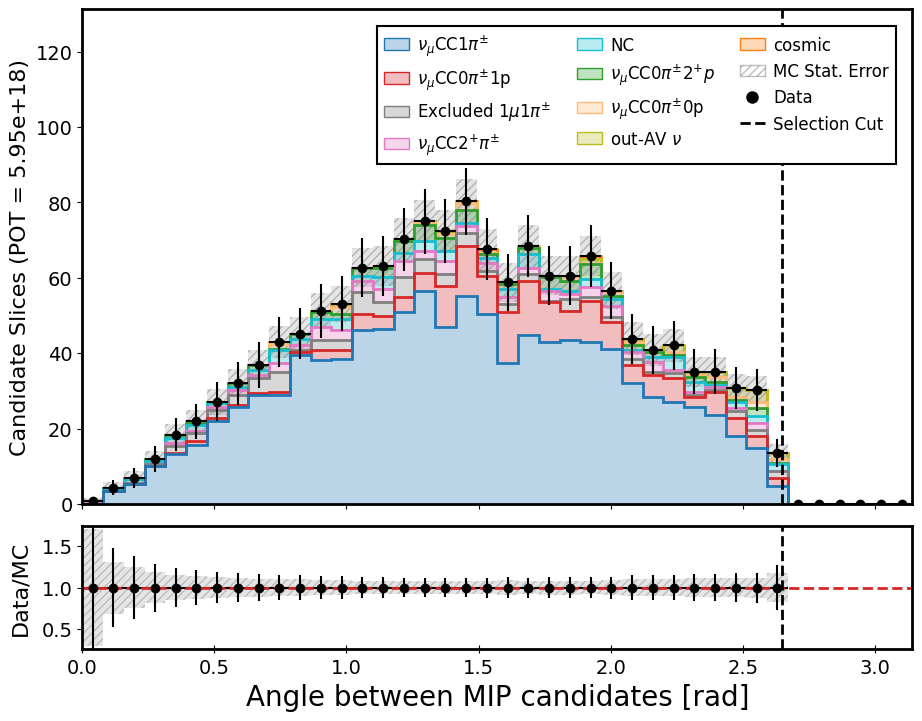

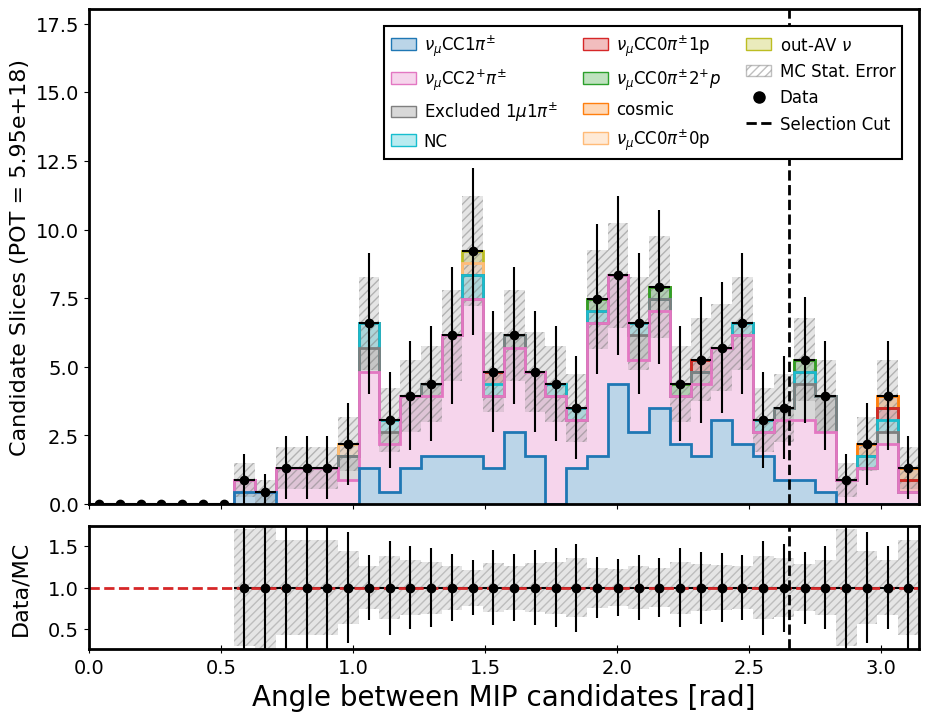

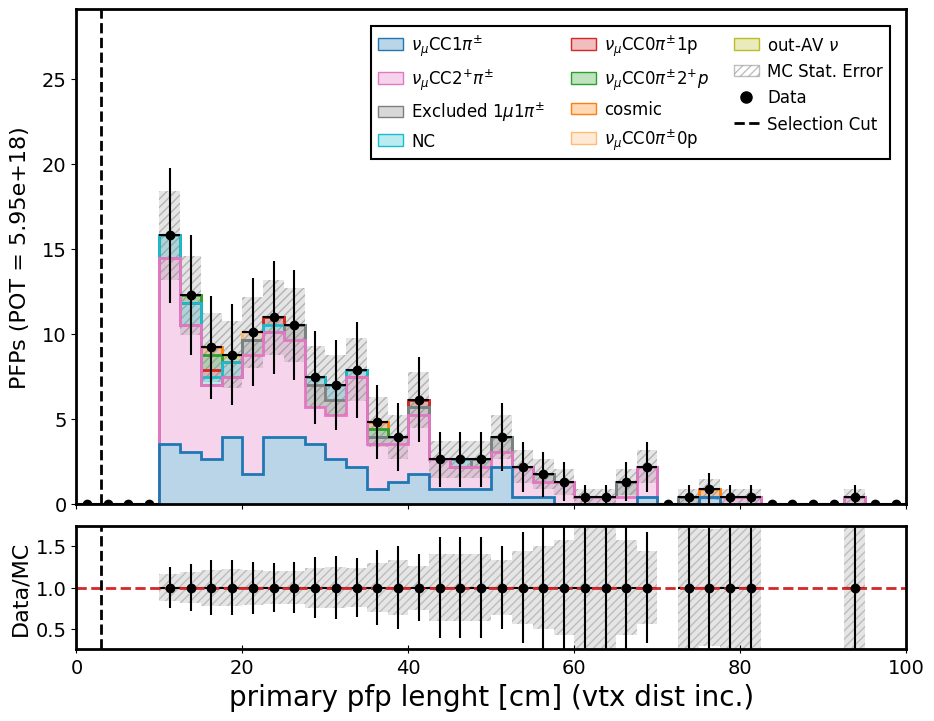

/tmp/ipykernel_97771/3221518280.py:115: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mc_control_evt_df[new_col] = [


KeyError: ('pfp', 'vars', 'len_diff_short', '', '', '')

In [63]:
WGT_COL = ('slc', 'wgt', '', '', '', '')

config_angle_between_candidates = FullHistogramConfig(
    file_name = "angle_between_candidates",      
    var_evt_reco_col=('slc','measure_var','angle_between_candidates','','',''),
    truth_column = nu_categ_column,
    first_per_slice = True,
    start_cut = "chi2",
    end_cut = "energy",
    bins=np.linspace(0, np.pi, 41),
    xlabel=r'Angle between MIP candidates [rad]',
    cut_value = [CTE.max_angle_between_candidates],
    ylabel=slices_y_label
)

config_max_angle_between_candidates = FullHistogramConfig(
    file_name = "angle_between_candidates",      
    var_evt_reco_col=('slc','measure_var','max_angle_between_candidates','','',''),
    truth_column = nu_categ_column,
    first_per_slice = True,
    start_cut = "chi2",
    end_cut = "energy",
    bins=np.linspace(0, np.pi, 41),
    xlabel=r'Angle between MIP candidates [rad]',
    cut_value = [CTE.max_angle_between_candidates],
    ylabel=slices_y_label
)

config_min_angle_between_candidates = FullHistogramConfig(
    file_name = "angle_between_candidates",      
    var_evt_reco_col=('slc','measure_var','min_angle_between_candidates','','',''),
    truth_column = nu_categ_column,
    first_per_slice = True,
    start_cut = "chi2",
    end_cut = "energy",
    bins=np.linspace(0, np.pi, 41),
    xlabel=r'Angle between MIP candidates [rad]',
    cut_value = [CTE.max_angle_between_candidates],
    ylabel=slices_y_label
)

config_analysis_primary_len = FullHistogramConfig(
    file_name = "analysis_primary_len", 
    var_evt_reco_col=('pfp','trk','len','','',''),
    truth_column=nu_categ_column,
    first_per_slice = True,
    start_cut = "nu_score",
    end_cut = "track",
    extra_mask = "analysis_primary",
    bins=np.linspace(0, 100, 41),
    xlabel='primary pfp lenght [cm] (vtx dist inc.)',
    ylabel= pfps_y_label,
    cut_value = [CTE.min_track_lenght],
    clip = False
)

config = config_angle_between_candidates
fig, red_chi2 = plot_stacked_histogram_with_ratio(
                mc_df=mc_signal_df, data_df=mc_signal_df, config=config,
                cov_frac_matrix=None, cov_matrix=None,
                title="", weight_column=WGT_COL,
                data_pot=data_tot_pot, normalize=False, show_stats=False, divide_by_bin_width = False
            )

config = config_max_angle_between_candidates
fig, red_chi2 = plot_stacked_histogram_with_ratio(
                mc_df=mc_control_evt_df, data_df=mc_control_evt_df, config=config,
                cov_frac_matrix=None, cov_matrix=None,
                title="", weight_column=WGT_COL,
                data_pot=data_tot_pot, normalize=False, show_stats=False, divide_by_bin_width = False
            )

len_col = ('pfp', 'trk', 'len', '', '', '')
idx_max = mc_control_evt_df[is_MIP_candidate_mask(mc_control_evt_df)].groupby(level=[0, 1])[[len_col]].idxmin()

# Note: .idxmin() on a DataFrame returns a Series where the index is 
# the group and the value is the MultiIndex of the row. 
# We need just the values (the row indices) for the mask.
idx_max_values = idx_max[len_col]

longest_particle_mask = mc_control_evt_df.index.isin(idx_max_values)
longest_particles_df = mc_control_evt_df[is_MIP_candidate_mask(mc_control_evt_df) & longest_particle_mask]
config = config_analysis_primary_len
fig, red_chi2 = plot_stacked_histogram_with_ratio(
                mc_df=longest_particles_df, data_df=longest_particles_df, config=config,
                cov_frac_matrix=None, cov_matrix=None,
                title="", weight_column=WGT_COL,
                data_pot=data_tot_pot, normalize=False, show_stats=False, divide_by_bin_width = False
            )

# 1. Define columns
len_col = ('pfp', 'trk', 'len', '', '', '')
new_col = ('analysis', 'vars', 'len_diff_short', '', '', '')

# 2. Get sorted tracks for MIP candidates
# We group by your specific levels to ensure we are within one slice
mask = is_MIP_candidate_mask(mc_control_evt_df)
sorted_df = mc_control_evt_df[mask].sort_values(by=len_col)

# 3. Get shortest and second shortest 
# Using a list for the levels to match your index names
levels = ['__ntuple', 'entry', 'rec.slc..index']
shortest = sorted_df.groupby(level=levels)[[len_col]].nth(0)[len_col]
second_shortest = sorted_df.groupby(level=levels)[[len_col]].nth(1)[len_col]

# 4. Calculate the difference Series
# This Series will now be indexed by (__ntuple, entry, rec.slc..index)
diff_series = second_shortest - shortest

# 5. Convert to a dictionary for a safe, index-agnostic mapping
diff_dict = diff_series.to_dict()

# 6. Map back to the main dataframe
# We iterate through the index levels to build the lookup key
mc_control_evt_df[new_col] = [
    diff_dict.get((ntup, ent, slc)) 
    for ntup, ent, slc, _ in mc_control_evt_df.index
]


config_analysis_len_diff_short = FullHistogramConfig(
    file_name = "analysis_primary_len", 
    var_evt_reco_col=('pfp','vars','len_diff_short','','',''),
    truth_column=nu_categ_column,
    first_per_slice = True,
    start_cut = "nu_score",
    end_cut = "track",
    extra_mask = "analysis_primary",
    bins=np.linspace(0, 100, 41),
    xlabel='primary pfp lenght [cm] (vtx dist inc.)',
    ylabel= pfps_y_label,
    cut_value = [CTE.min_track_lenght],
    clip = False
)

config = config_analysis_len_diff_short

fig, red_chi2 = plot_stacked_histogram_with_ratio(
                mc_df=longest_particles_df, data_df=longest_particles_df, config=config,
                cov_frac_matrix=None, cov_matrix=None,
                title="", weight_column=WGT_COL,
                data_pot=data_tot_pot, normalize=False, show_stats=False, divide_by_bin_width = False
            )


# Final vars

In [39]:

var_configs = [
    VariableConfig.all_evts(), 
    VariableConfig.muon_momentum(),
    VariableConfig.muon_direction(),
    VariableConfig.pion_momentum(),
    VariableConfig.pion_direction(),
    VariableConfig.angle_between_candidates(),
    VariableConfig.num_protons(),
    VariableConfig.delta_pt(),
    VariableConfig.delta_alpha_T(),
    VariableConfig.delta_phi_T()
]

In [ ]:
for var_config in var_configs:       
    fig, chi2 = plot_stacked_histogram_with_ratio(
        mc_GiBUU_evt_df[mc_GiBUU_evt_df.truth.nu_categ != "CC1pi"],
        mc_GiBUU_evt_df[mc_GiBUU_evt_df.truth.nu_categ != "CC1pi"],
        var_config,
        cov_frac_matrix = None,
        cov_matrix = None,
        weight_column = ('slc', 'wgt','','','',''),
        data_pot = data_tot_pot,
        show_stats = False,
        symmetric_ratio =  True,
        divide_by_bin_width = True
        )
    
    fig, chi2 = plot_stacked_histogram_with_ratio(
            mc_signal_df[mc_signal_df.truth.nu_categ != "CC1pi"],
            mc_signal_df[mc_signal_df.truth.nu_categ != "CC1pi"],
            var_config,
            cov_frac_matrix = None,
            cov_matrix = None,
            weight_column = ('slc', 'wgt','','','',''),
            data_pot = data_tot_pot,
            show_stats = False,
            symmetric_ratio =  True,
            divide_by_bin_width = True
            )

    fig, chi2 = plot_stacked_histogram_with_ratio(
            mc_control_evt_df[mc_control_evt_df.truth.nu_categ != "CC1pi"],
            mc_control_evt_df[mc_control_evt_df.truth.nu_categ != "CC1pi"],
            var_config,
            cov_frac_matrix = None,
            cov_matrix = None,
            weight_column = ('slc', 'wgt','','','',''),
            data_pot = data_tot_pot,
            show_stats = False,
            symmetric_ratio =  True,
            divide_by_bin_width = True
            )

    
    

In [ ]:
# --- CONFIGURATION TOGGLES ---
HIDE_COSMIC_BAR = False  
USE_LOG_SCALE = False
X_MIN_LOG = 10000     
# -----------------------------
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_selection_summary(masks_dict, df_source, title_suffix="", save_filename=None):
    """
    Processes masks and generates side-by-side Efficiency and Purity plots.
    """
    plot_data = []
    
    # 1. Process Masks
    for stage_name, mask in masks_dict.items():
        # Apply mask and group
        temp_df = df_source[mask].groupby(['__ntuple', 'entry', 'rec.slc..index']).first()
        
        if HIDE_COSMIC_BAR and stage_name == "cosmic":
            continue
            
        # Group by category and sum weights
        filtered_categs = temp_df.loc[:, [('truth','nu_categ','','','',''), pot_weight_col]]
        counts = filtered_categs.groupby([('truth','nu_categ','','','','')])[[pot_weight_col]].sum()
        
        counts = counts.iloc[:, 0]
        counts.name = stage_name
        plot_data.append(counts)

    # 2. Prepare DataFrames
    df_results = pd.concat(plot_data, axis=1).T.fillna(0)

    # Column ordering for CC1pi
    signal_tag = 'CC1pi'
    if signal_tag in df_results.columns:
        cols = [signal_tag] + [c for c in df_results.columns if c != signal_tag]
        df_results = df_results[cols]

    # Map colors and rename
    current_colors = [category_colors.get(col, "#000000") for col in df_results.columns]
    df_results_renamed = df_results.rename(columns=bkg_name_nice_map).rename(index=cut_name_nice_map)

    # 3. Create Subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

    # --- Efficiency Plot (Left) ---
    df_plot_efficiency = df_results_renamed[df_results_renamed.sum(axis=1) > 0]
    df_plot_efficiency.plot(kind='barh', stacked=True, ax=ax1, color=current_colors, legend=True)

    if USE_LOG_SCALE:
        ax1.set_xscale('log')
        max_val = df_plot_efficiency.sum(axis=1).max() * 5 
        ax1.set_xlim(X_MIN_LOG, max_val)

    ax1.set_title(f"$\\nu_\\mu$CC1$\\pi$ {title_suffix} Efficiency", fontsize=20, pad=15)
    ax1.set_xlabel("Candidate Slices", fontsize=18)
    ax1.grid(True, which="both", ls="-", alpha=0.2)
    ax1.tick_params(axis='both', labelsize=16)
    ax1.legend(loc='upper right', fontsize=18, framealpha=1.0, edgecolor='black', fancybox=False)

    # --- Purity Plot (Right) ---
    df_purity = df_results_renamed.div(df_results_renamed.sum(axis=1), axis=0)
    df_purity.plot(kind='barh', stacked=True, ax=ax2, color=current_colors, legend=False)

    ax2.set_title(f"$\\nu_\\mu$CC1$\\pi$ {title_suffix} Purity", fontsize=20, pad=15)
    ax2.set_xlabel("Fraction of Total Slices", fontsize=18)
    ax2.set_xlim(0, 1)
    ax2.set_xticks(np.arange(0, 1.1, 0.1))
    ax2.grid(True, axis='x', ls='--', alpha=0.6, color='gray', zorder=0)
    ax2.tick_params(axis='both', labelsize=16)

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.08)

    # 4. Save Logic
    if save_filename:
        parent_path = "/exp/sbnd/data/users/lpelegri/Graphs/PurEffGraphs"
        if not os.path.exists(parent_path):
            os.makedirs(parent_path)
        fig.savefig(os.path.join(parent_path, save_filename), format='pdf', bbox_inches='tight')
    
    plt.show()

# --- EXECUTION ---

# 1. Run for standard selection
plot_selection_summary(
    cumulative_masks, 
    mc_evt_df, 
    title_suffix="Selection", 
    save_filename="cc1pi_selection_summary.pdf"
)

# 2. Run for sideband
plot_selection_summary(
    sideband_cumulative_masks, 
    mc_evt_df, 
    title_suffix="Sideband", 
    save_filename="cc1pi_sideband_summary.pdf"
)

In [ ]:
signal_col = '$\\nu_{\\mu}$CC1$\\pi^{\\pm}$'
total_per_stage = df_results_renamed.sum(axis=1)

# 2. Calculate Purity: Signal / Total at each stage
purity = (df_results_renamed[signal_col] / total_per_stage) * 100

# 3. Calculate Efficiency: Signal at stage / Signal at first stage
# (Recreating num_events_0 logic)
initial_signal_count = df_results_renamed[signal_col].iloc[0]
efficiency = (df_results_renamed[signal_col] / initial_signal_count) * 100

# 4. Create a summary table for easy viewing
summary_df = pd.DataFrame({
    'Signal_Events': df_results_renamed[signal_col],
    'Total_Events': total_per_stage,
    'Purity (%)': purity,
    'Efficiency (%)': efficiency
})

print(summary_df)

In [ ]:
import numpy as np

print(f"{'Cut Name':<20} | {'Purity':<10} | {'Efficiency':<10} | {'S/sqrt(B)':<10} | {'pur * eff':<10}")
print("-" * 75)

for stage in df_results_renamed.index:
    n_signal = df_results_renamed.loc[stage, signal_col]
    n_total = total_per_stage.loc[stage]
    n_bkg = n_total - n_signal
    
    pur = (n_signal / n_total) * 100 if n_total > 0 else 0
    eff = (n_signal / initial_signal_count) * 100
    pur_eff = pur*eff/100
    s_sqrt_b = n_signal / np.sqrt(n_bkg) if n_bkg > 0 else np.nan
    
    print(f"{stage:<20} | {pur:>8.2f}% | {eff:>8.2f}% | {s_sqrt_b:>8.2f} | {pur_eff:8.2f}") 

In [ ]:
HelperFunctions.print_purity(slc_df[cumulative_masks["energy"]], ('truth','nu_categ','','','',''))

In [ ]:
print("0p")
HelperFunctions.print_purity(slc_df[cumulative_masks["energy"] & mask_dict["0p"](slc_df)], ('truth','nu_categ_proton_reduced','','','',''))
print("1p")
HelperFunctions.print_purity(slc_df[cumulative_masks["energy"] & mask_dict["1p"](slc_df)], ('truth','nu_categ_proton_reduced','','','',''))
print("2p+")
HelperFunctions.print_purity(slc_df[cumulative_masks["energy"] & mask_dict["2plusp"](slc_df)], ('truth','nu_categ_proton_reduced','','','',''))